In [5]:
import pathlib
from fastai.vision.all import PILImage, load_learner
import cv2
from matplotlib import pyplot as plt
import numpy as np
import torch
from fastai.callback.wandb import WandbCallback
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback

"""20 secondes à cause de l'initialisation de PyTorch via import torch, renforcée par fastai.vision.all"""

"20 secondes à cause de l'initialisation de PyTorch via import torch, renforcée par fastai.vision.all"

In [6]:
!pip install onnx onnxruntime


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
_temp = pathlib.PosixPath

pathlib.PosixPath = pathlib.WindowsPath

In [9]:
import torch
import torch.nn as nn
import torch.nn.utils as nn_utils
import torch.nn.utils.parametrize as parametrize
from fastai.vision.all import load_learner
import fastai.layers

# 1. Charger le Learner FastAI
modele_path = "final\\dartsify_ai_final_radius15.pkl"
print("Chargement du modèle FastAI...")
learn = load_learner(modele_path, cpu=True)
model = learn.model.eval().to('cpu')

# --- FIX 1 : Nettoyer la Spectral Normalization (Empêche le crash de SelfAttention) ---
def clean_spectral_norm(m):
    for name, module in m.named_modules():
        if hasattr(module, "parametrizations"):
            for key in list(module.parametrizations.keys()):
                try:
                    parametrize.remove_parametrizations(module, key, leave_parametrized=True)
                except Exception:
                    pass
        if hasattr(module, "weight_u"):
            try:
                nn_utils.remove_spectral_norm(module)
            except Exception:
                pass

# --- FIX 2 : Nettoyer les conversions FastAI (Empêche le crash du FakeTensor) ---
def strip_fastai_wrappers(m):
    for name, child in m.named_children():
        if isinstance(child, fastai.layers.ToTensorBase):
            setattr(m, name, nn.Identity()) # On remplace par une couche neutre
        else:
            strip_fastai_wrappers(child)

print("🔧 Nettoyage de l'architecture...")
clean_spectral_norm(model)
strip_fastai_wrappers(model)

# 2. Préparer l'image factice
# vu qu'on effectue un resize avant d'envoyer les images au modèle
dummy_input = torch.randn(1, 3, 360, 640).to('cpu')

# 3. Exportation directe vers ONNX
chemin_export = "final\\dartsify_ai_radius15.onnx"
print(f"Exportation directe vers {chemin_export}...")

with torch.no_grad():
    torch.onnx.export(
        model,                       # Le modèle nettoyé original (pas de traced_model)
        dummy_input,                 # Image factice
        chemin_export,               
        export_params=True,          
        opset_version=18,            # Opset 18 est parfaitement géré par PyTorch 2.x et nous évite les problèmes de compatibilité avec la fonction d'activation Mish
        do_constant_folding=True,    
        input_names=['input'],       
        output_names=['output'],
        # On débloque la dimension 0 pour autoriser le Batching de 3 images
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )

print("Modèle ONNX généré avec succès !")

Chargement du modèle FastAI...
🔧 Nettoyage de l'architecture...
Exportation directe vers final\dartsify_ai_radius15.onnx...


C:\Users\craig\AppData\Local\Temp\ipykernel_23672\3599478438.py:50: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `DynamicUnet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DynamicUnet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\craig\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Modèle ONNX généré avec succès !


In [ ]:
path_image = 'final\\saved_images\\cam2_lancer2.jpg'

In [5]:
def get_x(row):
    return row['image_path']

def get_mask(row):
    return row['mask_path']

In [6]:
learn = load_learner(r"final\\dartsify_ai_final_radius15.pkl")

c:\Users\craig\Documents\UNIVERSITE DE MONS\BAC3-Polytech\Q2\ProjetIG\algorithme-de-reconnaissance\.venv\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [7]:
learn.dls.after_item.fs

[AddMaskCodes(enc:0,dec:1), RandomCrop -- {'size': (512, 512), 'p': 1.0}
(enc:1,dec:0), ToTensor(enc:2,dec:0)]

In [8]:
transformations_sans_crop = [tfm for tfm in learn.dls.after_item.fs if 'Crop' not in type(tfm).__name__]

In [9]:
transformations_sans_crop

[AddMaskCodes(enc:0,dec:1), ToTensor(enc:2,dec:0)]

In [10]:
# NETTOYAGE CRITIQUE : On supprime les callbacks d'entraînement pour l'inférence
if WandbCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(WandbCallback)

if SaveModelCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(SaveModelCallback)

if EarlyStoppingCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(EarlyStoppingCallback)

In [11]:
image = PILImage.create(path_image)

In [12]:
after_item  = learn.dls.after_item     # resize, ToTensor, etc.
after_batch = learn.dls.after_batch    # Normalize, IntToFloat, etc.
 
x = after_item(image)              # apply item transforms
x = after_batch(x[None])               # add batch dim
 
learn.model.eval()
with torch.no_grad():
    out = learn.model(x.to(learn.dls.device))
    out = out.argmax(dim=1)

# Debug : vérifier la somme des valeurs du masque (normalement différent de 0 si il y a des points)
print("Somme des valeurs du masque :", out[0].numpy().sum())


Somme des valeurs du masque : 1303


Aire détectée : 625.5
La fléchètte se trouve en : (177, 187)


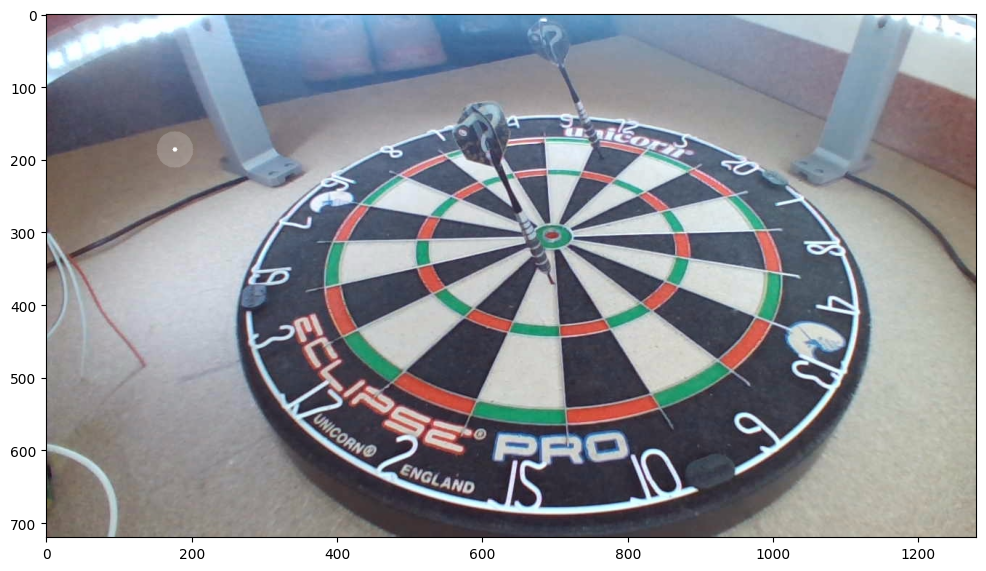

In [13]:
mask = out[0].numpy()

# garder seulement la classe "Point"
mask = (mask == 1).astype(np.uint8) * 255
"""
Etape post-traitement de l'image de sortie du modèle pour trouver les coordonnées de la fléchette
et les afficher sur l'image d'origine
"""
mask = cv2.convertScaleAbs(mask)

# trouver les contours de la fléchette
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# contours = imutils.grab_contours(contours)
contours = [contour for contour in contours if cv2.contourArea(contour) >= 600]

if not contours:
    print("Aucun contour détecté.")
else:
    image_np = np.array(image)  # Convertir PILImage en tableau NumPy (format RGB)
    image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)  # Convertir RGB en BGR pour OpenCV
    output = image_bgr.copy()
    MIN_AREA = 600  # Seuil d'aire pour filtrer les petits contours (ajuster selon les résultats)

    for c in contours:
        area = cv2.contourArea(c)
        print(f"Aire détectée : {area}")  # Observe les petites valeurs vs les grandes

        # if area < MIN_AREA:
        #     continue

        M = cv2.moments(c)

        if M["m00"] == 0:
            cX, cY, largeur, hauteur = cv2.boundingRect(c)
            cX, cY = cX + largeur // 2, cY + hauteur // 2
        else:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

        print("La fléchètte se trouve en :", (cX, cY))

        overlay = output.copy()

        color = (255, 255, 255)
        cv2.circle(overlay, (cX, cY), 25, color, -1)

        alpha = 0.2
        cv2.addWeighted(overlay, alpha, output, 1 - alpha, 0, output)

        cv2.circle(output, (cX, cY), 3, color, -1)

    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    # plt.axis('off')
    plt.show()